# Apprentissage supervisé : machines à vecteurs supports

# Table of contents
1. [Machines à vecteurs supports pour la classification](#part1)
1. [Machines à vecteurs supports pour la régression](#part2)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [2]:
def covariance(sigma1=1., sigma2=1., theta=0.):
    """
        Covariance matrix with eigenvalues sigma1 and sigma2, rotated by the angle theta.
    """
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                        [np.sin(theta), np.cos(theta)]])
    cov = np.array([[sigma1, 0.],
                   [0, sigma2]])
    return rotation.dot(cov.dot(rotation.T))


def gaussian_sample(mu=[0, 0], sigma1=1., sigma2=1., theta=0., n=50):
    cov = covariance(sigma1, sigma2, theta)
    x = multivariate_normal.rvs(mean=mu, cov=cov, size=n)
    return x


def plot_frontiere(functions, data=None, data_labels=None, num=500, label=None):
    """
        Plot the frontiere fun(x)=0 of the classifier clf within the same range as the one
        of the data.
        Input:
            functions: scoring function or list of scoring functions (typically clf.decision_function)
            data: input data (X)
            data_labels: data labels (y)
            num: discretization parameter
            label: scoring functions labels as a list
    """
    if not hasattr(functions, '__iter__'):
        functions = [functions]
    if label is not None and not hasattr(label, '__iter__'):
        label = [label]
        
    xmin, ymin = data.min(axis=0)
    xmax, ymax = data.max(axis=0)
    x, y = np.meshgrid(np.linspace(xmin, xmax, num), np.linspace(ymin, ymax))
    
    plt.figure(figsize=(7, 7))
    plt.scatter(*data.T, c=data_labels, cmap='plasma')
    
    for i, fun in enumerate(functions):
        z = fun(np.c_[x.ravel(), y.ravel()]).reshape(x.shape)
        cs = plt.contour(x, y, z, [0], colors='r')
        if label is not None:
            cs.levels = [label[i]]
            plt.gca().clabel(cs)
    plt.axis('image')
    minx, miny = data[:, 0].min(), data[:, 1].min()
    diffx, diffy = data[:, 0].max() - minx, data[:, 1].max() - miny
    plt.axis([minx - 0.1*diffx, minx + 1.1*diffx, miny - 0.1*diffy, miny + 1.1*diffy])

# Machines à vecteurs supports pour la classification <a id="part1"></a>


<div class="alert alert-block alert-info">
Lancer le script suivant pour étudier le comportement des machines à vecteurs supports.    
<!-- <br> -->
</div>

In [3]:
"""
==========
Libsvm GUI
==========

A simple graphical frontend for Libsvm mainly intended for didactic
purposes. You can create data points by point and click and visualize
the decision region induced by different kernels and parameter settings.

To create positive examples click the left mouse button; to create
negative examples click the right button.

If all examples are from the same class, it uses a one-class SVM.

"""
from __future__ import division

print(__doc__)

# Author: Peter Prettenhofer <peter.prettenhofer@gmail.com>
#
# License: BSD Style.

import warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use('TkAgg')

try:
    # Python 3.5
    from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
    from matplotlib.backends.backend_tkagg import NavigationToolbar2TkAgg
except ImportError:
    # Python 3.7
    from matplotlib.backends.backend_tkagg import FigureCanvas as FigureCanvasTkAgg
    from matplotlib.backends.backend_tkagg import NavigationToolbar2Tk as NavigationToolbar2TkAgg

from matplotlib.figure import Figure
from matplotlib.contour import ContourSet

try:
    import tkinter as Tk
except ImportError:
    # Backward compatibility for Python 2
    import Tkinter as Tk

import sys
import numpy as np

from sklearn import svm

y_min, y_max = -50, 50
x_min, x_max = -50, 50


class Model(object):
    """The Model which hold the data. It implements the
    observable in the observer pattern and notifies the
    registered observers on change event.
    """

    def __init__(self):
        self.observers = []
        self.surface = None
        self.data = []
        self.cls = None
        self.surface_type = 0

    def changed(self, event):
        """Notify the observers. """
        for observer in self.observers:
            observer.update(event, self)

    def add_observer(self, observer):
        """Register an observer. """
        self.observers.append(observer)

    def set_surface(self, surface):
        self.surface = surface


class Controller(object):
    def __init__(self, model):
        self.model = model
        self.kernel = Tk.IntVar()
        self.surface_type = Tk.IntVar()
        # Whether or not a model has been fitted
        self.fitted = False

    def fit(self):
        print("fit the model")
        train = np.array(self.model.data)
        X = train[:, :2]
        y = train[:, 2]

        C = float(self.complexity.get())
        gamma = float(self.gamma.get())
        coef0 = float(self.coef0.get())
        degree = int(self.degree.get())
        kernel_map = {0: "linear", 1: "rbf", 2: "poly"}
        if len(np.unique(y)) == 1:
            clf = svm.OneClassSVM(kernel=kernel_map[self.kernel.get()],
                      gamma=gamma, coef0=coef0, degree=degree)
            clf.fit(X)
        else:
            clf = svm.SVC(kernel=kernel_map[self.kernel.get()], C=C,
                          gamma=gamma, coef0=coef0, degree=degree)
            clf.fit(X, y)
        if hasattr(clf, 'score'):
            print("Accuracy:", clf.score(X, y) * 100)
        X1, X2, Z = self.decision_surface(clf)
        self.model.clf = clf
        self.model.set_surface((X1, X2, Z))
        self.model.surface_type = self.surface_type.get()
        self.fitted = True
        self.model.changed("surface")

    def decision_surface(self, cls):
        delta = 1
        x = np.arange(x_min, x_max + delta, delta)
        y = np.arange(y_min, y_max + delta, delta)
        X1, X2 = np.meshgrid(x, y)
        Z = cls.decision_function(np.c_[X1.ravel(), X2.ravel()])
        Z = Z.reshape(X1.shape)
        return X1, X2, Z

    def clear_data(self):
        self.model.data.clear()
        self.fitted = False
        self.surface = None
        self.model.changed("clear")

    def add_example(self, x, y, label):
        self.model.data.append((x, y, label))
        self.model.changed("example_added")

        # update decision surface if already fitted.
        self.refit()

    def refit(self):
        """Refit the model if already fitted. """
        if self.fitted:
            self.fit()


class View(object):
    """Test docstring. """
    def __init__(self, root, controller):
        f = Figure()
        ax = f.add_subplot(111)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim((x_min, x_max))
        ax.set_ylim((y_min, y_max))
        canvas = FigureCanvasTkAgg(f, master=root)
        canvas.draw()
        canvas.get_tk_widget().pack(side=Tk.TOP, fill=Tk.BOTH, expand=1)
        canvas._tkcanvas.pack(side=Tk.TOP, fill=Tk.BOTH, expand=1)
        canvas.mpl_connect('button_press_event', self.onclick)
        toolbar = NavigationToolbar2TkAgg(canvas, root)
        toolbar.update()
        self.controllbar = ControllBar(root, controller)
        self.f = f
        self.ax = ax
        self.canvas = canvas
        self.controller = controller
        self.contours = []
        self.c_labels = None
        self.plot_kernels()

    def plot_kernels(self):
        self.ax.text(-50, -60, "Linear: $u^T v$")
        self.ax.text(-20, -60, "RBF: $\exp (-\gamma \| u-v \|^2)$")
        self.ax.text(10, -60, "Poly: $(\gamma \, u^T v + r)^d$")

    def onclick(self, event):
        if event.xdata and event.ydata:
            if event.button == 1:
                self.controller.add_example(event.xdata, event.ydata, 1)
            elif event.button == 3:
                self.controller.add_example(event.xdata, event.ydata, -1)

    def update(self, event, model):
        if event == "example_added":
            x, y, l = model.data[-1]
            if l == 1:
                color = 'b'
            elif l == -1:
                color = 'g'
            self.ax.plot([x], [y], "%so" % color, scalex=0.0, scaley=0.0)

        if event == "clear":
            self.ax.clear()
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_xlim((x_min, x_max))
            self.ax.set_ylim((y_min, y_max))
            self.contours = []
            self.c_labels = None
            self.plot_kernels()

        if event == "surface":
            self.remove_surface()
            self.plot_support_vectors(model.clf.support_vectors_)
            self.plot_decision_surface(model.surface, model.surface_type)

        self.canvas.draw()

    def remove_surface(self):
        """Remove old decision surface."""
        if len(self.contours) > 0:
            for contour in self.contours:
                if isinstance(contour, ContourSet):
                    for lineset in contour.collections:
                        lineset.remove()
                else:
                    contour.remove()
            self.contours = []

    def plot_support_vectors(self, support_vectors):
        """Plot the support vectors by placing circles over the
        corresponding data points and adds the circle collection
        to the contours list."""
        cs = self.ax.scatter(support_vectors[:, 0], support_vectors[:, 1],
                             s=100, edgecolors="r", facecolors="none")
        self.contours.append(cs)

    def plot_decision_surface(self, surface, type):
        X1, X2, Z = surface
        if type == 0:
            levels = [-1.0, 0.0, 1.0]
            linestyles = ['dashed', 'solid', 'dashed']
            colors = 'k'
            self.contours.append(self.ax.contour(X1, X2, Z, levels,
                                                 colors=colors,
                                                 linestyles=linestyles))
        elif type == 1:
            self.contours.append(self.ax.contourf(X1, X2, Z, 10,
                                             cmap=matplotlib.cm.bone,
                                             origin='lower',
                                             alpha=0.85))
            self.contours.append(self.ax.contour(X1, X2, Z, [0.0],
                                                 colors='k',
                                                 linestyles=['solid']))
        else:
            raise ValueError("surface type unknown")


class ControllBar(object):
    def __init__(self, root, controller):
        fm = Tk.Frame(root)
        kernel_group = Tk.Frame(fm)
        Tk.Radiobutton(kernel_group, text="Linear", variable=controller.kernel,
                       value=0, command=controller.refit).pack(anchor=Tk.W)
        Tk.Radiobutton(kernel_group, text="RBF", variable=controller.kernel,
                       value=1, command=controller.refit).pack(anchor=Tk.W)
        Tk.Radiobutton(kernel_group, text="Poly", variable=controller.kernel,
                       value=2, command=controller.refit).pack(anchor=Tk.W)
        kernel_group.pack(side=Tk.LEFT)

        valbox = Tk.Frame(fm)
        controller.complexity = Tk.StringVar()
        controller.complexity.set("1.0")
        c = Tk.Frame(valbox)
        Tk.Label(c, text="C:", anchor="e", width=7).pack(side=Tk.LEFT)
        Tk.Entry(c, width=6, textvariable=controller.complexity).pack(
            side=Tk.LEFT)
        c.pack()

        controller.gamma = Tk.StringVar()
        controller.gamma.set("0.01")
        g = Tk.Frame(valbox)
        Tk.Label(g, text="gamma:", anchor="e", width=7).pack(side=Tk.LEFT)
        Tk.Entry(g, width=6, textvariable=controller.gamma).pack(side=Tk.LEFT)
        g.pack()

        controller.degree = Tk.StringVar()
        controller.degree.set("3")
        d = Tk.Frame(valbox)
        Tk.Label(d, text="degree:", anchor="e", width=7).pack(side=Tk.LEFT)
        Tk.Entry(d, width=6, textvariable=controller.degree).pack(side=Tk.LEFT)
        d.pack()

        controller.coef0 = Tk.StringVar()
        controller.coef0.set("0")
        r = Tk.Frame(valbox)
        Tk.Label(r, text="coef0:", anchor="e", width=7).pack(side=Tk.LEFT)
        Tk.Entry(r, width=6, textvariable=controller.coef0).pack(side=Tk.LEFT)
        r.pack()
        valbox.pack(side=Tk.LEFT)

        cmap_group = Tk.Frame(fm)
        Tk.Radiobutton(cmap_group, text="Hyperplanes",
                       variable=controller.surface_type, value=0,
                       command=controller.refit).pack(anchor=Tk.W)
        Tk.Radiobutton(cmap_group, text="Surface",
                       variable=controller.surface_type, value=1,
                       command=controller.refit).pack(anchor=Tk.W)

        cmap_group.pack(side=Tk.LEFT)

        train_button = Tk.Button(fm, text='Fit', width=5,
                                 command=controller.fit)
        train_button.pack()
        fm.pack(side=Tk.LEFT)
        Tk.Button(fm, text='Clear', width=5,
                  command=controller.clear_data).pack(side=Tk.LEFT)


def run_svm_gui():
    root = Tk.Tk()
    model = Model()
    controller = Controller(model)
    root.wm_title("Scikit-learn Libsvm GUI")
    view = View(root, controller)
    model.add_observer(view)
    Tk.mainloop()
    
run_svm_gui()



Libsvm GUI

A simple graphical frontend for Libsvm mainly intended for didactic
purposes. You can create data points by point and click and visualize
the decision region induced by different kernels and parameter settings.

To create positive examples click the left mouse button; to create
negative examples click the right button.

If all examples are from the same class, it uses a one-class SVM.




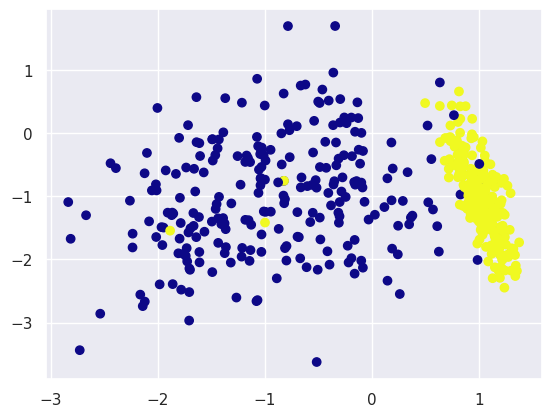

In [4]:
# Classification dataset
%matplotlib inline

from sklearn.datasets import make_classification

X, y = make_classification(n_samples=500, n_classes=2,
                           n_features=2, n_redundant=0, n_clusters_per_class=1)

plt.scatter(*X.T, c=y, cmap='plasma')

<div class="alert alert-block alert-info">

Afficher les frontières de classification obtenues en faisant varier le paramètre `C` de `sklearn.svm.SVC`.    

<!-- <br> -->
</div>

In [ ]:
# Answer
from sklearn.svm import SVC

clf = SVC(kernel="linear")

C_values = np.logspace(-3, 2, num=10)
score = []
for C in C_values:
    clf.set_params(C=C)
    # Fit the model
    # Todo

    # End todo
    score.append(clf.score(X, y))
    
    # Plot the decision boundary
    # Todo

    # End todo

<div class="alert alert-block alert-info">

Afficher le score de classification pour chaque valeur du paramètre `C`.

<!-- <br> -->
</div>

In [ ]:
# Answer

# Machines à vecteurs supports pour la régression <a id="part2"></a>


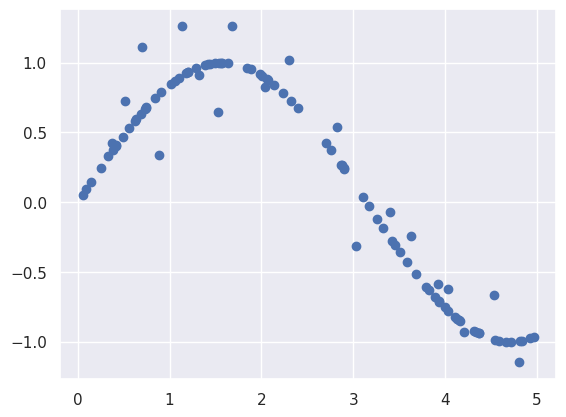

In [7]:
# Regression dataset
n = 100
X_train = np.sort(5 * np.random.rand(n))
y_train = np.sin(X_train)
y_train[::5] += 1 * (0.5 - np.random.rand(n//5))

X_test = np.arange(0, 5, step=1e-2)
y_test = np.sin(X_test)

# Make 2d-arrays
X_train = X_train[:, np.newaxis]
X_test = X_test[:, np.newaxis]

plt.scatter(X_train, y_train)

<div class="alert alert-block alert-info">

Afficher la courbe de régression obtenue avec `sklearn.svm.SVR`.

<!-- <br> -->
</div>

In [ ]:
# Answer